TensorFlow Version: 2.20.0
✅ CSV Loaded successfully. Available Columns:
['image_id', 'file_path', 'parent_class', 'grade', 'shelf_life_days', 'green_ratio', 'red_ratio', 'dark_spot_ratio', 'mold_ratio', 'texture_roughness', 'preventive_measure']


/tmp/ipykernel_867/3758409551.py:111: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  lookup = df[df[path_col].astype(str).str.contains(filename, case=False, na=False)]
/tmp/ipykernel_867/3758409551.py:111: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  lookup = df[df[path_col].astype(str).str.contains(filename, case=False, na=False)]


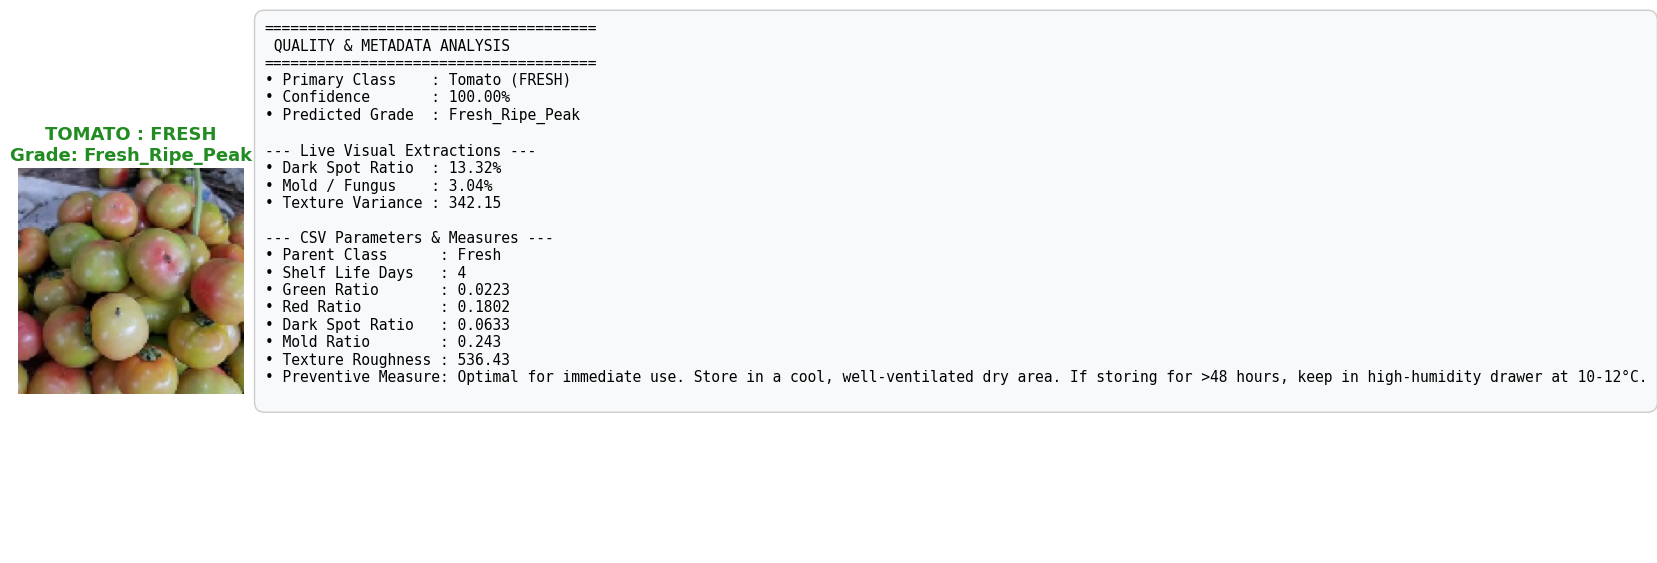


 TOP 3 PREDICTIONS
1. tomato_fresh           -> 100.00%
2. tomato_rotten          ->   0.00%
3. potato_fresh           ->   0.00%



In [6]:
import os
import cv2
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow.keras.preprocessing import image
import matplotlib.pyplot as plt

print(f"TensorFlow Version: {tf.__version__}")

# ==========================================
# 1. Configuration & Paths
# ==========================================
MODEL_PATH = '/content/best_model.keras'
CSV_PATH = '/content/annotated_tomatoes_dataset.csv'  # Path to your CSV metadata file
TEST_IMAGE = '/content/freshTomato (10).jpg'
IMAGE_SIZE = (128, 128)
CLASS_NAMES = [
    'apple_fresh', 'apple_rotten',
    'banana_fresh', 'banana_rotten',
    'bellpepper_fresh', 'bellpepper_rotten',
    'carrot_fresh', 'carrot_rotten',
    'cucumber_fresh', 'cucumber_rotten',
    'grape_fresh', 'grape_rotten',
    'guava_fresh', 'guava_rotten',
    'jujube_fresh', 'jujube_rotten',
    'mango_fresh', 'mango_rotten',
    'orange_fresh', 'orange_rotten',
    'pomegranate_fresh', 'pomegranate_rotten',
    'potato_fresh', 'potato_rotten',
    'strawberry_fresh', 'strawberry_rotten',
    'tomato_fresh', 'tomato_rotten'
]

# Load Model
model = tf.keras.models.load_model(MODEL_PATH, compile=False)

# Load CSV and clean column headers
df_params = pd.read_csv(CSV_PATH)
df_params.columns = df_params.columns.str.strip()
print("✅ CSV Loaded successfully. Available Columns:")
print(list(df_params.columns))

# ==========================================
# 2. Visual Parameter Extraction (CV Metrics)
# ==========================================
def extract_visual_metrics(img_path):
    """Calculates live visual parameters to complement CSV lookups."""
    img_bgr = cv2.imread(img_path)
    if img_bgr is None:
        return {"dark_spot_ratio": 0.0, "texture_roughness": 0.0, "mold_ratio": 0.0}

    img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
    hsv = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2HSV)

    # Dark / decay spots
    lower_dark = np.array([0, 30, 20])
    upper_dark = np.array([30, 255, 100])
    dark_mask = cv2.inRange(hsv, lower_dark, upper_dark)
    dark_spot_ratio = (np.sum(dark_mask > 0) / (img_rgb.shape[0] * img_rgb.shape[1])) * 100

    # Mold / fungal white-grey patches
    lower_mold = np.array([0, 0, 160])
    upper_mold = np.array([180, 40, 255])
    mold_mask = cv2.inRange(hsv, lower_mold, upper_mold)
    mold_ratio = (np.sum(mold_mask > 0) / (img_rgb.shape[0] * img_rgb.shape[1])) * 100

    # Texture roughness
    gray = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY)
    texture_var = cv2.Laplacian(gray, cv2.CV_64F).var()

    return {
        "dark_spot_ratio": round(float(dark_spot_ratio), 2),
        "mold_ratio": round(float(mold_ratio), 2),
        "texture_roughness": round(float(texture_var), 2)
    }

# ==========================================
# 3. Tomato Sub-Grade Predictor
# ==========================================
def predict_tomato_grade(condition, confidence, metrics):
    dark_spots = metrics["dark_spot_ratio"]
    mold = metrics["mold_ratio"]

    if condition == 'fresh':
        if confidence > 90.0 and dark_spots < 3.0:
            return "Fresh_Early_Firm"
        else:
            return "Fresh_Ripe_Peak"
    else:
        if mold > 5.0 or dark_spots > 20.0:
            return "Rotten_Severe_Fungal"
        elif dark_spots > 8.0:
            return "Rotten_Moderate_Decay"
        else:
            return "Rotten_Early_Spoilage"

# ==========================================
# 4. Safe CSV Data Retrieval
# ==========================================
def fetch_csv_parameters(df, img_path, assigned_grade, parent_class):
    """
    Tries matching by exact file name first, then by 'grade', then by 'parent_class'.
    """
    filename = os.path.basename(img_path)
    lookup = pd.DataFrame()

    # Strategy 1: Match by filename/path if present
    for path_col in ['file_path', 'image_id']:
        if path_col in df.columns:
            lookup = df[df[path_col].astype(str).str.contains(filename, case=False, na=False)]
            if not lookup.empty:
                return lookup.iloc[0].to_dict()

    # Strategy 2: Match by exact Grade
    if 'grade' in df.columns:
        lookup = df[df['grade'].astype(str).str.strip().str.lower() == assigned_grade.lower()]
        if not lookup.empty:
            return lookup.iloc[0].to_dict()

    # Strategy 3: Match by Parent Class (fresh vs rotten or tomato_fresh vs tomato_rotten)
    for parent_col in ['parent_class', 'parent_cla', 'class']:
        if parent_col in df.columns:
            lookup = df[df[parent_col].astype(str).str.strip().str.lower().isin([parent_class.lower(), parent_class.split('_')[-1]])]
            if not lookup.empty:
                return lookup.iloc[0].to_dict()

    # Fallback to the first row if no condition matched
    return df.iloc[0].to_dict() if len(df) > 0 else {}

# ==========================================
# 5. Main Prediction & Visual Dashboard
# ==========================================
def predict_and_analyze(img_path, model=model, df_params=df_params):
    # 1. Model Inference
    raw_img = image.load_img(img_path, target_size=IMAGE_SIZE)
    img_array = image.img_to_array(raw_img) / 255.0
    img_tensor = np.expand_dims(img_array, axis=0)

    raw_preds = model.predict(img_tensor, verbose=0)[0]
    pred_idx = np.argmax(raw_preds)
    pred_label = CLASS_NAMES[pred_idx]
    confidence = float(raw_preds[pred_idx] * 100)

    item, condition = pred_label.split('_')

    # 2. Extract CV Metrics & Predict Sub-grade
    metrics = extract_visual_metrics(img_path)
    if item.lower() == 'tomato':
        predicted_grade = predict_tomato_grade(condition, confidence, metrics)
    else:
        predicted_grade = f"{condition.capitalize()}_Standard"

    # 3. Retrieve CSV Details
    csv_details = fetch_csv_parameters(df_params, img_path, predicted_grade, pred_label)

    # 4. Visualization Dashboard
    fig, (ax_img, ax_txt) = plt.subplots(1, 2, figsize=(14, 6), gridspec_kw={'width_ratios': [1, 1.3]})

    # Left: Image
    ax_img.imshow(raw_img)
    ax_img.axis('off')
    status_color = 'forestgreen' if condition == 'fresh' else 'firebrick'
    ax_img.set_title(
        f"{item.upper()} : {condition.upper()}\nGrade: {predicted_grade}",
        fontsize=13,
        fontweight='bold',
        color=status_color
    )

    # Right: Parameters Text Panel
    ax_txt.axis('off')
    dashboard_text = f"{'='*38}\n QUALITY & METADATA ANALYSIS\n{'='*38}\n"
    dashboard_text += f"• Primary Class    : {item.title()} ({condition.upper()})\n"
    dashboard_text += f"• Confidence       : {confidence:.2f}%\n"
    dashboard_text += f"• Predicted Grade  : {predicted_grade}\n\n"

    dashboard_text += f"--- Live Visual Extractions ---\n"
    dashboard_text += f"• Dark Spot Ratio  : {metrics['dark_spot_ratio']}%\n"
    dashboard_text += f"• Mold / Fungus    : {metrics['mold_ratio']}%\n"
    dashboard_text += f"• Texture Variance : {metrics['texture_roughness']}\n\n"

    dashboard_text += f"--- CSV Parameters & Measures ---\n"
    ignore_cols = ['image_id', 'file_path', 'grade']
    for k, v in csv_details.items():
        if k not in ignore_cols:
            clean_key = k.replace('_', ' ').title()
            dashboard_text += f"• {clean_key:<18}: {v}\n"

    ax_txt.text(
        0.02, 0.98, dashboard_text,
        transform=ax_txt.transAxes,
        fontsize=10.5,
        verticalalignment='top',
        fontfamily='monospace',
        bbox=dict(boxstyle='round,pad=0.7', facecolor='#f8f9fa', edgecolor='#cccccc')
    )

    plt.tight_layout()
    plt.show()

    # 5. Top 3 Predictions Printout
    print(f"\n{'='*38}\n TOP 3 PREDICTIONS\n{'='*38}")
    top_indices = np.argsort(raw_preds)[-3:][::-1]
    for rank, idx in enumerate(top_indices, 1):
        print(f"{rank}. {CLASS_NAMES[idx]:<22} -> {raw_preds[idx] * 100:6.2f}%")
    print(f"{'='*38}\n")

# Run Analysis
predict_and_analyze(TEST_IMAGE)